# Тема 1. Моделирование геометрической вероятности

Смоделируйте вычисление геометрической вероятности (на примере из лекции про метание дротиков в игровой круг, площадь которого в два раза меньше площади стены). Показать теоретический расчет и графическую иллюстрацию для рассматриваемого примера.

## Задача

**Задача: «Посадка космического дрона»**

Космический дрон совершает аварийную посадку на прямоугольную платформу размером **12 × 8 м**. Считается, что точка посадки равновероятно может оказаться в любой точке платформы.

В центре платформы расположена посадочная зона в форме **кольца**:

* внешний радиус \($R=3$\) м;
* внутренний радиус \($r=1$\) м.

Внутренний круг — это антенна станции, приземляться на которую нельзя. Дрон успешно приземляется, если попадает **в кольцевую область вокруг антенны**.

Найти теоретическую вероятность успешной посадки и проверить её методом статистического моделирования, случайным образом сгенерировав, например, **10 000 посадок**.

In [29]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
import random
import numpy as np

### Теоретический расчёт

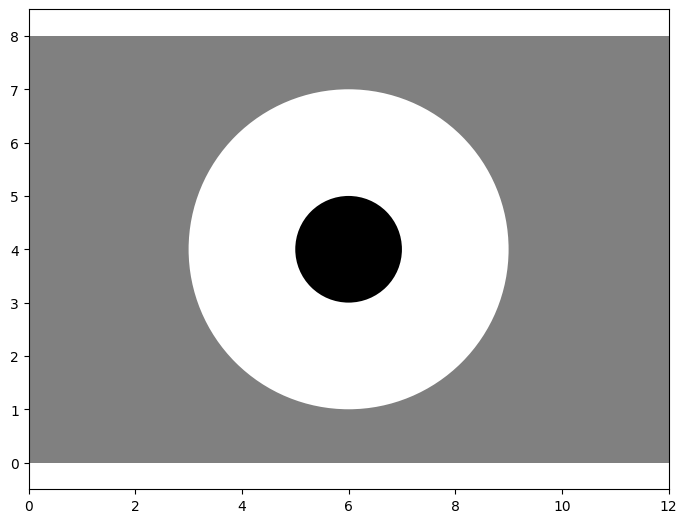

In [58]:
fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1])
plt.xlim(0, 12)
plt.ylim(0, 8)
plt.axis('equal') # Чтобы деления одинаковой величины выглядели одинаково


platform = Rectangle((0, 0), 12, 8, facecolor="gray")
circ1 = Circle((6, 4), 3, facecolor="white")
circ2 = Circle((6, 4), 1, facecolor="black")
ax.add_patch(platform)
ax.add_patch(circ1)
ax.add_patch(circ2)
plt.show()

Рассмотрим событие A - дрон совершил успешную посадку.  
Найдём площадь прямоугольной площадки и площадь кольца:
$$ {\mathrm{S}}_{прям.пл}=12\times 8 $$
$${\mathrm{S}}_{кольца}={\mathrm{S}}_{внеш.окр}-{\mathrm{S}}_{внутр.окр}=9\pi -\pi $$

In [61]:
s_rect = 12 * 8
s_ring = 9 * np.pi - np.pi
print(s_rect)
print(round(s_ring, 4))

96
25.1327


$$\mathrm{P}(\mathrm{A})=\frac{{\mathrm{S}}_{кольца}}{{\mathrm{S}}_{прям.пл}}=\frac{25.1327}{96}$$

In [63]:
round(s_ring / s_rect, 4)

0.2618

### Графическая иллюстрация

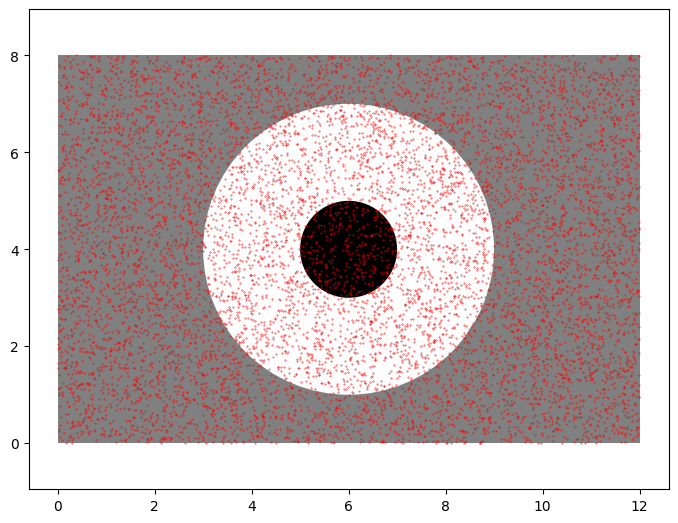

Кол-во попадания дрона в зону из 10000 попыток: 2624. Вероятность попадания составила:  0.2624


In [57]:
fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1])
plt.xlim(0, 12)
plt.ylim(0, 8)
plt.axis('equal') # Чтобы деления одинаковой величины выглядели одинаково


platform = Rectangle((0, 0), 12, 8, facecolor="gray")
circ1 = Circle((6, 4), 3, facecolor="white")
circ2 = Circle((6, 4), 1, facecolor="black")
ax.add_patch(platform)
ax.add_patch(circ1)
ax.add_patch(circ2)


x = np.random.uniform(0, 12, 10_000)
y = np.random.uniform(0, 8, 10_000)

plt.scatter(x, y, s=0.1, c="red")
mask = ((x - 6) ** 2 + (y - 4) ** 2 < 9) & ((x - 6) ** 2 + (y - 4) ** 2 > 1)
success = x[mask]

plt.show()
print("Кол-во попадания дрона в зону из 10000 попыток: " + str(len(success)) + ". Вероятность попадания составила: ", len(success) / 10_000)